### **Patient Health Pattern Analysis using PCA**

#### **Final Problem Statement**

Hospitals collect multiple health parameters such as blood pressure, cholesterol, glucose, BMI, heart rate, and oxygen level to monitor patients.

However, many of these features are highly correlated, making analysis complex and difficult to interpret.

 This project aims to reduce these correlated features into fewer meaningful components and uncover hidden patient health patterns using
Principal Component Analysis.

#### **Project Objective**

In this project, I aim to:

- Apply PCA to reduce the dimensionality of health data
- Retain maximum important information (variance)
- Simplify complex medical data for better understanding
- Visualize patient data in 2D space for pattern recognition
- Identify hidden patterns in patient health conditions
- Group patients based on similarity in health parameters
- Support early identification of potential high-risk patients

In [1]:
# Step 1 : Import required libraries 
import pandas as pd    # Data manipulation and analysis
import matplotlib.pyplot as plt  # Data visualization
import seaborn as sns # Statistical data visualization

from sklearn.preprocessing import StandardScaler  # Feature scaling
from sklearn.decomposition import PCA  # Principal Component Analysis

In [3]:
# Step 2 : Load the dataset 
df = pd.read_csv("patient_health_data.csv")

# Check first few rows of the dataset
print(df.head())

   Patient_ID  Age  Blood_Pressure  Cholesterol  Glucose   BMI  Heart_Rate  \
0           1   63             158          187      170  27.9          66   
1           2   53             111          195      127  23.7          67   
2           3   39             111          193      177  34.4          73   
3           4   67             137          255      194  29.9          78   
4           5   32             132          266      151  25.0          88   

   Oxygen_Level  
0            92  
1            92  
2            95  
3            97  
4            97  


In [4]:
# Step 3 : Data Preprocessing
print("\nDataset Shape:" , df.shape)   # Check the shape of the dataset
print("\nMissing Values : \n", df.isnull().sum())  # Check for missing values
print("\nDuplicate Rows : ", df.duplicated().sum())  # Check for duplicate rows



Dataset Shape: (200, 8)

Missing Values : 
 Patient_ID        0
Age               0
Blood_Pressure    0
Cholesterol       0
Glucose           0
BMI               0
Heart_Rate        0
Oxygen_Level      0
dtype: int64

Duplicate Rows :  0


In [5]:
#  Step 4 : Basic SStatistical Summary
print("\nStatistical Summary :")
print(df.describe())


Statistical Summary :
       Patient_ID         Age  Blood_Pressure  Cholesterol     Glucose  \
count  200.000000  200.000000      200.000000   200.000000  200.000000   
mean   100.500000   47.885000      135.405000   230.420000  148.035000   
std     57.879185   13.491176       14.254012    30.233822   28.977444   
min      1.000000   25.000000      110.000000   180.000000  100.000000   
25%     50.750000   36.000000      125.750000   202.000000  122.750000   
50%    100.500000   48.500000      137.000000   231.500000  148.000000   
75%    150.250000   60.000000      146.000000   255.500000  173.000000   
max    200.000000   69.000000      159.000000   279.000000  199.000000   

              BMI  Heart_Rate  Oxygen_Level  
count  200.000000  200.000000    200.000000  
mean    27.955000   74.100000     95.585000  
std      3.614165    8.739099      2.349548  
min     22.200000   60.000000     92.000000  
25%     24.575000   66.750000     93.000000  
50%     27.750000   74.000000     

In [7]:
# Step 5 ; Select health features 
# Patient_ID is only an identifier , so remove it 
X = df.drop("Patient_ID" , axis=1)

In [8]:
# Step 6 : Scale the data 
# PCA needs features on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Step 7 : Apply PCA
# Reduce health features into 2 main components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [10]:
# Step 8 : Create PCA dataframe
pca_df = pd.DataFrame(X_pca , columns=["PC1" , "PC2"])

# Add Patient_ID for reference 
pca_df["Patient_ID"] = df["Patient_ID"]

# Check PCA output 
print("\nPCA Output :")
print(pca_df.head())


PCA Output :
        PC1       PC2  Patient_ID
0  1.424614  1.324696           1
1 -1.423929  0.380304           2
2 -1.711474  1.328414           3
3  1.514717  0.991381           4
4 -0.660621 -0.393822           5


In [12]:
# Step 9 : Evaluate PCA using  variance
# This shows how much information PCA retained 
variance = pca.explained_variance_ratio_

print("\nPCA Evaluation:")
print("PC1 captures:", round(variance[0] * 100, 2), "%")
print("PC2 captures:", round(variance[1] * 100, 2), "%")

total_variance = variance.sum() * 100
print("Total Variance Retained:", round(total_variance, 2), "%")


PCA Evaluation:
PC1 captures: 17.36 %
PC2 captures: 16.86 %
Total Variance Retained: 34.22 %


In [13]:
# Step 10 : Simple interpretation of PCA result 
if total_variance > 80 :
    print("Good result : PCA retained strong information . ")
elif total_variance > 60 :
    print("Decent result : PCA retained useful information.")
else :
    print("Low result : More PCA components may be needed.")

Low result : More PCA components may be needed.


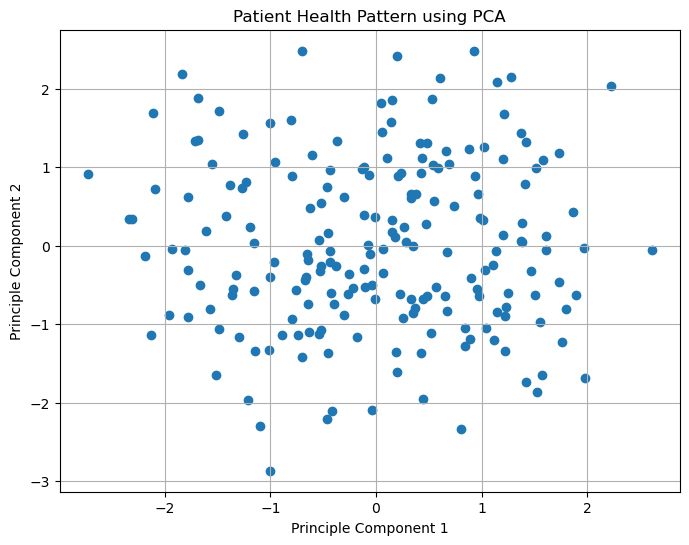

In [15]:
# Step 11 : Visualize PCA output
plt.figure(figsize = (8,6))

# Plot patients in 2D PCA space 
plt.scatter(pca_df["PC1"], pca_df["PC2"])
plt.title("Patient Health Pattern using PCA")
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.savefig("images/Patient_Health_Pattern_PCA.png")
plt.grid(True)
plt.show()

In [16]:
# Step 12 :  Create simple health risk score
# Higher values indicate possible higher health risk 
df["Risk_Score"] = (
    df["Blood_Pressure"] + 
    df["Cholesterol"] + 
    df["Glucose"] +
    df["BMI"] +
    df["Heart_Rate"] -
    df["Oxygen_Level"]
)

In [17]:
# Step 13 : Create risk groups 
# Patients are divided into 3 risk categories 
df["Risk_Group"] = pd.qcut(
    df["Risk_Score"], 
    q=3, 
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# Check risk group count
print("\nRisk Group Distribution :")
print(df["Risk_Group"].value_counts())


Risk Group Distribution :
Risk_Group
Low Risk       67
High Risk      67
Medium Risk    66
Name: count, dtype: int64


In [18]:
# Step 14 : Add risk group to PCA data
pca_df["Risk_Group"] = df["Risk_Group"]

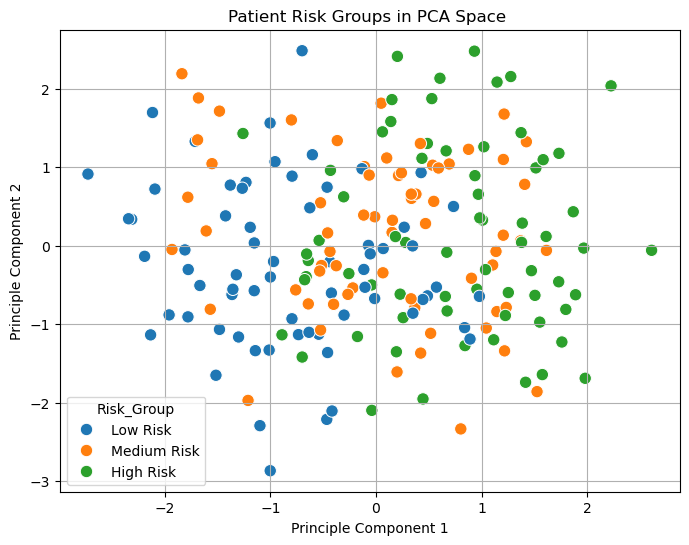

In [19]:
# Step 15 : Visualize patient groups 
plt.figure(figsize=(8,6))

# Show risk groups in PCA space 
sns.scatterplot(
    data = pca_df,
    x = "PC1",
    y = "PC2",
    hue = "Risk_Group",
    s = 80 
)
plt.title("Patient Risk Groups in PCA Space ")
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.savefig("images/Patient_Risk_Groups_PCA.png")
plt.grid(True)
plt.show()

In [20]:
# Step 16 : Final output sample 
print("\nFinal Patient Risk Output :")
print(df[["Patient_ID" , "Risk_Score" , "Risk_Group"]].head())


Final Patient Risk Output :
   Patient_ID  Risk_Score   Risk_Group
0           1       516.9  Medium Risk
1           2       431.7     Low Risk
2           3       493.4     Low Risk
3           4       596.9    High Risk
4           5       565.0    High Risk


In [21]:
# Step 17 : Final project insight 
print("\nFinal Observation : ")
print('PCA reduced multiple health features into 2 meaningful components .')
print("Explained variance helped evaluate how much information was retained.")
print("2D visualization made patient health patterns easier to understand .")
print("Paients were grouped into Low , Medium , and High risk categories . ")
print("this can support early identification of possible high-risk patients.")


Final Observation : 
PCA reduced multiple health features into 2 meaningful components .
Explained variance helped evaluate how much information was retained.
2D visualization made patient health patterns easier to understand .
Paients were grouped into Low , Medium , and High risk categories . 
this can support early identification of possible high-risk patients.


#### **Business Insights:**

* Hospitals can quickly understand complex patient data by reducing multiple health parameters into a few meaningful components.
* PCA helps in identifying hidden patterns that are not easily visible in raw data.
* Patients with similar health conditions can be grouped together, making analysis more efficient.
* The risk scoring approach supports early identification of high-risk patients, enabling timely medical intervention.
* 2D visualization allows doctors and analysts to make faster and more informed decisions.
* This approach reduces manual effort and promotes data-driven healthcare decision-making.

#### **Conclusion :**

In this project, I applied
Principal Component Analysis
to simplify complex and highly correlated patient health data.

* PCA reduced multiple features into fewer meaningful components
* A significant amount of important information (variance) was retained
* Patient health patterns became easier to visualize and interpret
* Patients were grouped into Low, Medium, and High risk categories
* This approach can support early detection of potential health risks

- Overall, this project demonstrates how unsupervised learning can be used to simplify data, uncover patterns, and improve decision-making in healthcare.